# Readme

Plot responses by type.

In [1]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data_folder = "../../data/preprocessed-data"

df_rois = pd.concat([pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])

# Plot function

In [3]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):
    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

In [4]:
swc_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-norm/c6fb66deed2b53502e41fdcec0caa3b9'
swc_files = [f for f in os.listdir(swc_dir) if f.endswith('.swc')]

In [5]:
morph_folder = "../../data/morphological-data"
morph_spreadsheet_filename = "Eyewire II Proofread Cells Master List - All Cells 2025-09-09.csv"

df_master = pd.read_csv(os.path.join(os.path.join(morph_folder, morph_spreadsheet_filename)), dtype=str)

nuc_col_master = 'Updated Nuc ID (Sept 2)'
seg_col_master = 'Updated Seg ID (Sept 2)'
assert seg_col_master in df_master.columns, f"Column '{seg_col_master}' not found in df_master"
assert nuc_col_master in df_master.columns, f"Column '{nuc_col_master}' not found in df_master"

print(df_master.shape)
df_master.head()

(8687, 35)


,Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,Final NucID,...,Machine soma location,Additional Notes,Index OK?,Index for sanity check,Updated Nuc ID (Sept 2),Updated Seg ID (Sept 2),Cell Requires Review (DO NOT use Updated IDs for those cells),Review complete,Review notes,Cutoff Severity for Status=Complete (cut off) cells (%Hits Edge & Can't Fix Annotations in Proofreading link)
0,A4,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A4,NaN,NaN,FALSE,NaN,NaN,NaN
1,A5,NaN,NaN,OFF-SAC,Christine,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A5,NaN,NaN,FALSE,NaN,NaN,NaN
2,A7,"63573, 49070, 1720","63537, 49048, 1697",OFF-SAC,April Grace,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940545056597,...,INL,NaN,ok,A7,720575940545056597,720575940572159335,FALSE,NaN,NaN,NaN
3,A11,"50561, 64354, 1734","50520, 64370, 1656",OFF-SAC,Roden Rey,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940544186175,...,INL,NaN,ok,A11,720575940544186175,720575940563309953,FALSE,NaN,NaN,NaN
4,A12,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,INL,NaN,ok,A12,NaN,NaN,FALSE,NaN,NaN,NaN


In [6]:
df_merged = pd.merge(
    df_master.set_index(nuc_col_master),
    df_rois.set_index(df_rois['nuc_id'].astype(str)),
    left_index=True, right_index=True, how='inner'
).reset_index()

print(df_merged.shape)
df_merged.head()

(379, 105)


,Updated Nuc ID (Sept 2),Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,...,cluster_id,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,seg_id,nuc_id
0,720575940577751704,D1,"32653.0,23923.0,553.0","32653.0,23923.0,583.0",NaN,Elison,Greg,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,18,12,ON-OFF,0.804667,0.819760,0.832646,0.913740,"[0.0020822615335256726, 0.0032838992937911002,...",720575940550529705,720575940577751704
1,720575940534317101,D2,"33159.0,22959.0,606.0","33159.0,22959.0,661.0",NaN,Juliane,Jonathan,Complete,Annotated,https://spelunker.cave-explorer.org/#!middleau...,...,51,34,dAC,0.605752,0.615440,0.702638,0.702638,"[0.003336756586838654, 0.008818983121221289, 0...",720575940568652126,720575940534317101
2,720575940554891618,D3,"33787.0,21853.0,597.0","33787.0,21853.0,677.0",ON-SAC,Nseraf,Juliane,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,68,42,dAC,0.772927,0.790771,0.927322,0.927322,"[0.0017071109567420337, 0.0016375104799094017,...",720575940572885792,720575940554891618
3,720575940554657378,D4,"34131.0,21306.0,627.0","34131.0,21306.0,657.0",NaN,Christine,NaN,Complete,AC,https://spelunker.cave-explorer.org/#!middleau...,...,74,46,dAC,0.488712,0.494132,0.803859,0.803859,"[0.0028589256378742686, 0.003341772704406851, ...",720575940566222700,720575940554657378
4,720575940571117757,D5,"34753.0,20187.0,669.0","34753.0,20187.0,684.0",NaN,Glenda,Greg,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,...,38,28,Slow ON,0.580714,0.581366,0.590559,0.629739,"[0.0012246466912174362, 0.0011384551512382875,...",720575940577371948,720575940571117757


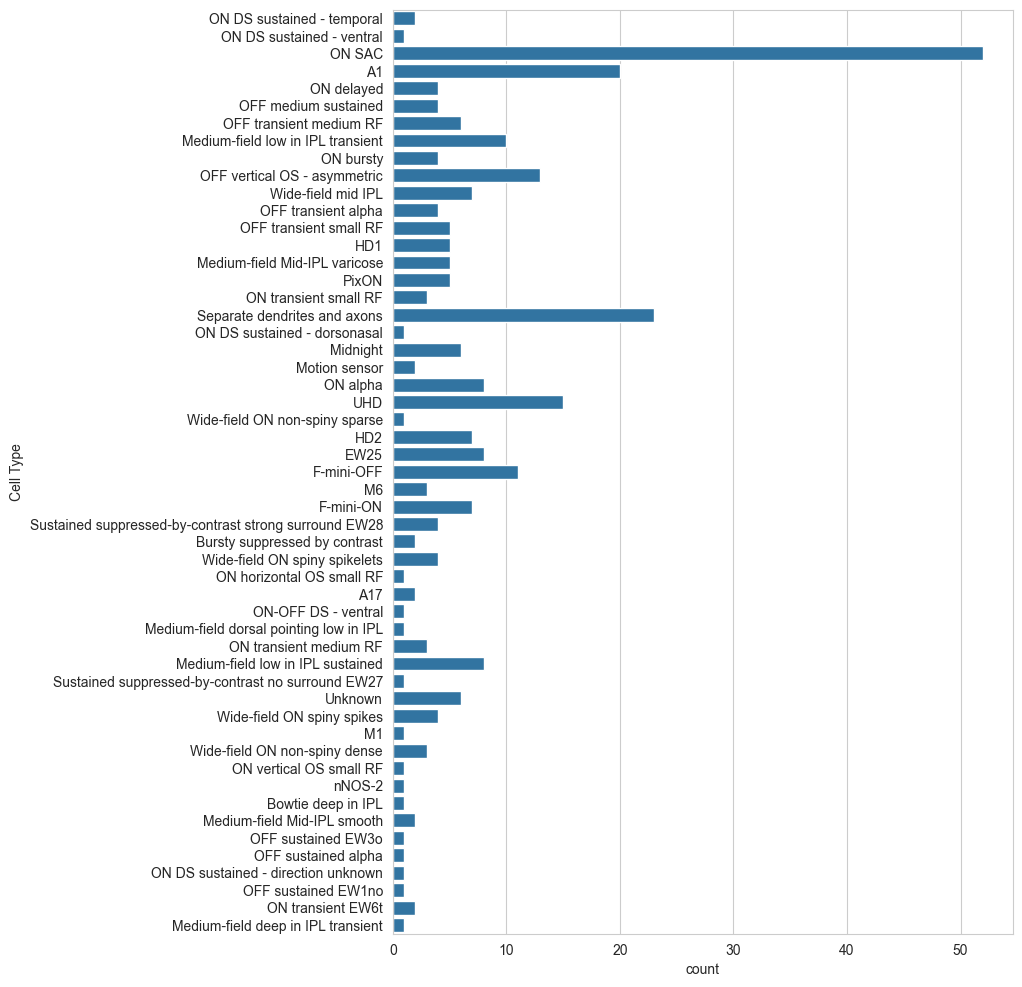

In [7]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [8]:
t_chirp = np.arange(df_merged.chirp_average_norm.iloc[0].size) * df_merged.chirp_average_dt.iloc[0]
t_bar = np.arange(df_merged.bar_time_component.iloc[0].size) * df_merged.bar_snippets_dt.iloc[0]

In [9]:
import skeliner as sk
from utils import plot_chirp, plot_bar_dir, plot_morph, plot_bar, plot_mosaic, plot_scale_bar

In [18]:
def add_skels(df):
    df = df.copy()

    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(swc_dir, f"{x}.swc"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']].swc_path)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_swc(x))
    return df

def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 4, figsize=(8, len(df) * 0.9), width_ratios=(1, 2, 2, 1))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    for i, (seg_id, row) in enumerate(df.iterrows()):
        rad = 200
        sx, sy, sz = plot_morph(ax=axs[i, 0], row=row, rad=rad)
        plot_scale_bar(ax=axs[i, 0], x0=sx-0.95*rad+50, y0=sy+0.95*rad, size=100, text=False)
        axs[i, 0].set_rasterized(True)

        plot_chirp(ax=axs[i, 1], row=row)
        if i == (df.shape[0] - 1):
            plot_scale_bar(ax=axs[i, 1], x0=1, y0=-0.4, size=2, text=True, tdist=0.1, unit='s')

        plot_bar(ax=axs[i, 2], row=row, annotate_dirs=False, annotate_symbols=True)
        if i == (df.shape[0] - 1):
            plot_scale_bar(ax=axs[i, 2], x0=1, y0=-0.2, size=2, text=True, tdist=0.1, unit='s')

        plot_bar_dir(ax=axs[i, 3], row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.4, w_pad=0.2)
    return fig, axs

In [19]:
fig_dir = './figures/examples'
os.makedirs(fig_dir, exist_ok=True)

In [20]:
list(df_merged.columns)

['Updated Nuc ID (Sept 2)',
 'Index',
 'Nuc Coords',
 'Soma Coords',
 'Cell Type (deprecated)',
 '611 Proofreader',
 'Proofreader 2',
 'Status',
 'AIS annotated?',
 'Final Link',
 'Final NucID',
 'Final SegID',
 'Directionality',
 'Proofreading Notes',
 'Status (Julia)',
 'Notes (Julia)',
 'Cell Class',
 'Cell Typer Name',
 'Cell Type',
 'Reliability Human Label',
 'Other Type',
 'EyeWire1 type (for RGCs) human label',
 'Reliability EyeWire1 human label',
 'Labeling Notes',
 'Machine label',
 'Confidence machine label',
 'Machine soma location',
 'Additional Notes',
 'Index OK?',
 'Index for sanity check',
 'Updated Seg ID (Sept 2)',
 'Cell Requires Review (DO NOT use Updated IDs for those cells)',
 'Review complete',
 'Review notes',
 "Cutoff Severity for Status=Complete (cut off) cells                          (%Hits Edge & Can't Fix Annotations in Proofreading link)",
 'experimenter',
 'date',
 'exp_num',
 'raw_id',
 'field',
 'region',
 'cond1',
 'ch0_name',
 'ch1_name',
 'roi_id',

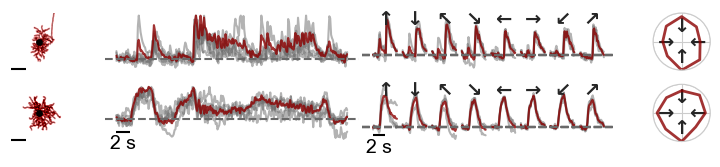

In [21]:
# For Sebastian
df_type = df_merged[
    (df_merged['roi_id'].astype(int).isin([62, 52]))
    & (df_merged["field"] == 'GCL2')
]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

fig, axs = plot_cells(df_type)
plt.savefig(os.path.join(fig_dir, 'examples_GCL2_52_62.svg'), transparent=True, dpi=600)
plt.show()

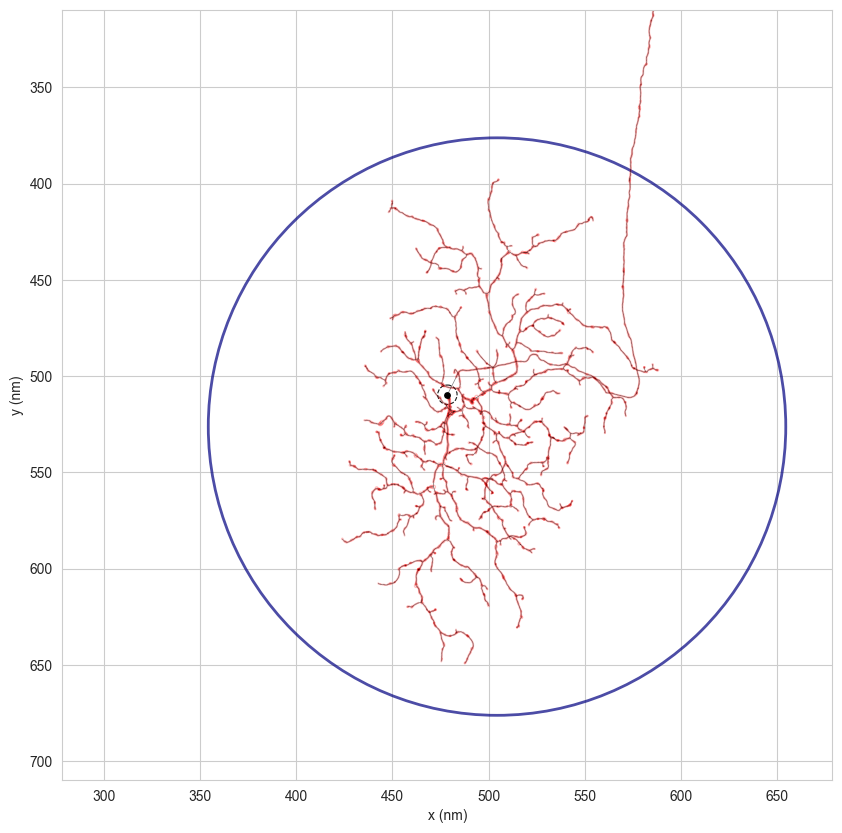

In [22]:
row = add_skels(df_type).iloc[0]

dorsal_offset = row['ventral_dorsal_pos_um'] - row['field_ventral_dorsal_pos_um']
nasal_offset = row['temporal_nasal_pos_um'] - row['field_temporal_nasal_pos_um']

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sx, sy, sz = plot_morph(ax=ax, row=row, rad=200)


import matplotlib.patches as patches


circle = patches.Circle((sx-nasal_offset, sy-dorsal_offset), radius=150,
                       facecolor='none',
                       edgecolor='navy',
                       linewidth=2,
                       alpha=0.7)
ax.add_patch(circle)


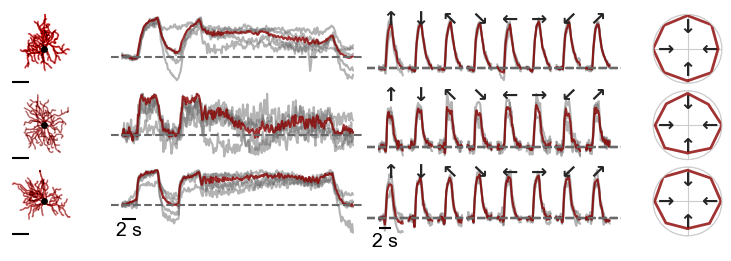

In [26]:
son_alpha_list = [720575940557469707, 720575940562911131, 720575940572157287, 720575940575066105]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(son_alpha_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])

plt.savefig(os.path.join(fig_dir, 'examples_son_alphas.svg'), transparent=True, dpi=600)

[720575940563265819 720575940572551485 720575940576369093
 720575940562015742 720575940546061452 720575940583667923
 720575940551647474 720575940547919816 720575940576381125
 720575940561194713 720575940579488144 720575940560950763]


,Updated Seg ID (Sept 2),Cell Type,Machine label
45,720575940563265819,UHD,5ti
50,720575940572551485,UHD,5ti
54,720575940576369093,UHD,5ti
90,720575940562015742,UHD,5ti
96,720575940546061452,UHD,5ti
105,720575940583667923,UHD,5ti
151,720575940551647474,UHD,5ti
164,720575940547919816,UHD,5ti
168,720575940576381125,UHD,5ti
186,720575940561194713,UHD,5ti


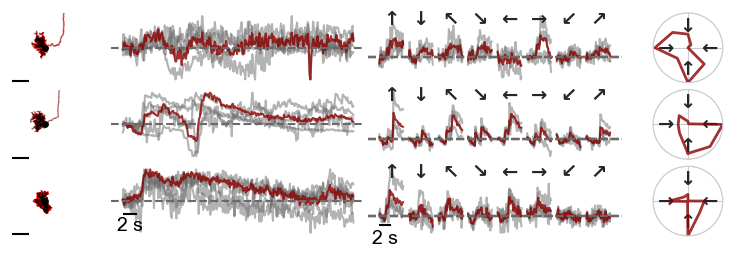

In [27]:
uhd_list = [720575940546061452, 720575940547919816, 720575940551647474, 720575940560950763, 720575940561194713,
            720575940562015742, 720575940563265819, 720575940572551485, 720575940576369093,
            720575940576381125, 720575940579488144, 720575940583667923]

df_type = df_merged[
    #((df_merged['Cell Type'] == 'UHD') | ((df_merged['Machine label'] == '5ti') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    (df_merged[seg_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))
display(df_type[[seg_col_master, 'Cell Type', 'Machine label']])

# fig, axs = plot_cells(df_type)
# plt.savefig(os.path.join(fig_dir, 'examples_all_uhd.svg'), transparent=True, dpi=600)
# plt.show()

fig, axs = plot_cells(df_type.iloc[[2, 4, -1]])
plt.savefig(os.path.join(fig_dir, 'examples_uhd.svg'), transparent=True, dpi=600, bbox_inches='tight')
plt.show()

# fig, ax = plot_mosaic(add_skels(df_type), extent = (330, 980, 0, 650))
# plt.savefig(os.path.join(fig_dir, 'mosaic_uhd.pdf'))
# plt.show()

[720575940563567973 720575940576092590 720575940581355463
 720575940563588453]


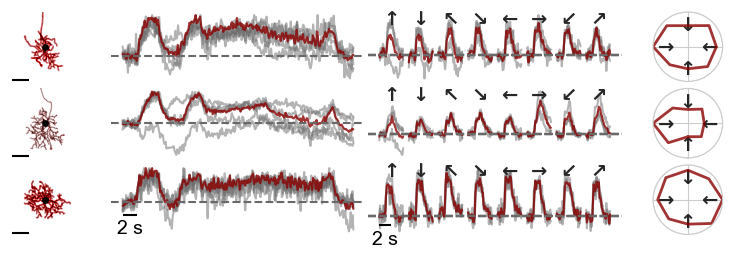

In [28]:
pixon_list = [720575940563567973, 720575940563588453, 720575940576092590, 720575940581355463]

df_type = df_merged[
    ((df_merged['Cell Type'] == 'PixON') | (
            (df_merged['Machine label'] == '9n') & (df_merged['Confidence machine label'].astype(float) > 0.5)))
    #(df_merged[seg_col_master].astype(int).isin(pixon_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
    ]
df_type = df_type.drop_duplicates(subset=[seg_col_master], keep='first')

print(df_type[seg_col_master].values.astype(int))

fig, axs = plot_cells(df_type.iloc[[0, 1, 3]])
plt.savefig(os.path.join(fig_dir, 'examples_pixon.svg'), transparent=True, dpi=600, bbox_inches='tight')